In [3]:
#import libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 6, 'weights': 'distance'}
Accuracy Score: 0.9444444444444444


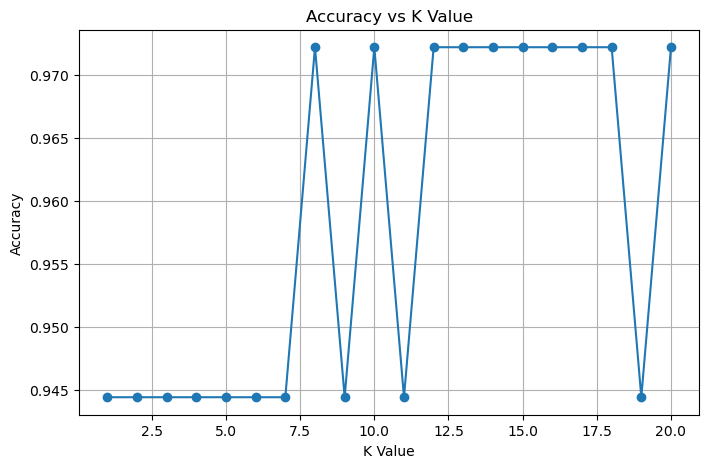

Confusion Matrix:
 [[14  0  0]
 [ 1 12  1]
 [ 0  0  8]]


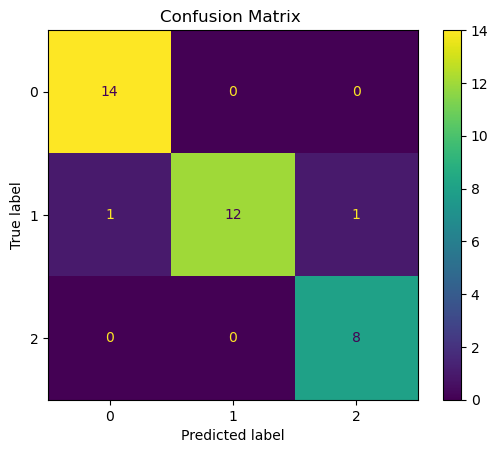

In [13]:
#Dataset, Features and Target Variables
data=load_wine()
X=data.data
y=data.target

#Train-Test
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

#Standard Scaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

#Hypertuning
param_grid={
    'n_neighbors':range(1,21),
    'weights':['uniform','distance'],
    'metric':['euclidean']
}

#Model
model=KNeighborsClassifier()
grid=GridSearchCV(
    model,param_grid,cv=8,scoring='accuracy'
)
grid.fit(X_train,y_train)

#Best Parameter
print("Best Parameters:",grid.best_params_)

#Best Model
best_model=grid.best_estimator_

#Predictions
y_pred=best_model.predict(X_test)

#Evaluations
acc=accuracy_score(y_test,y_pred)
print("Accuracy Score:",acc)

#K value Vs Accuracy
k_values = range(1, 21)
accuracy_values = []

for k in k_values:
    
    model = KNeighborsClassifier(
        n_neighbors=k,
        metric='euclidean'
    )
    
    model.fit(X_train, y_train)
    
    pred = model.predict(X_test)
    
    accuracy_values.append(
        accuracy_score(y_test, pred)
    )

plt.figure(figsize=(8,5))

plt.plot(k_values, accuracy_values, marker='o')

plt.title("Accuracy vs K Value")
plt.xlabel("K Value")
plt.ylabel("Accuracy")

plt.grid(True)
plt.show()

#Matrix
con=confusion_matrix(y_test,y_pred)
print("Confusion Matrix:\n",con)

disp=ConfusionMatrixDisplay(confusion_matrix=con)
disp.plot()
plt.title("Confusion Matrix ")
plt.show()